# GSBS vs fast_GSBS — speed & result comparison

Runs the original `GSBS` and the accelerated `fast_GSBS` on the **same placeholder
data** (400 voxels × 1000 TRs), and checks that they return identical boundaries
while `fast_GSBS` runs several times faster.

`fast_GSBS` is a subclass of `GSBS`, so it inherits everything in your fork
(including your plotting helpers) and only swaps the compute-heavy internals.

## 1 · Install your fork

On Colab this pulls the package straight from GitHub.

In [1]:
!pip install -q "git+https://github.com/drgzkr/statesegmentation.git"

import statesegmentation, numpy as np, time
print("statesegmentation from:", statesegmentation.__file__)
from statesegmentation import GSBS, fast_GSBS
print("imported GSBS and fast_GSBS OK  |  fast_GSBS is subclass:", issubclass(fast_GSBS, GSBS))

  Preparing metadata (setup.py) ... done
statesegmentation from: /usr/local/lib/python3.12/dist-packages/statesegmentation/__init__.py
imported GSBS and fast_GSBS OK  |  fast_GSBS is subclass: True


## 2 · Placeholder data (200 voxels × 400 TRs)

GSBS expects `x` with shape **(timepoints, voxels)** = **(T, V)**. So a
"200 features × 400 timepoints" dataset is passed as an array of shape
**(400, 200)**. Here we build blocky data (piecewise-constant multivoxel
patterns + noise) so there are real states to find.

In [2]:
T, V, N_STATES = 400, 200, 40          # timepoints, voxels, ground-truth states
rng = np.random.RandomState(0)
bnds = np.sort(rng.choice(np.arange(1, T), N_STATES - 1, replace=False))
patterns = rng.randn(N_STATES, V)
labels = np.zeros(T, int)
for b in bnds:
    labels[b:] += 1
x = (patterns[labels] + rng.randn(T, V) * 1.0).astype(float)   # shape (T, V) = (1000, 400)
print("x shape (timepoints, voxels):", x.shape)

x shape (timepoints, voxels): (400, 200)


## 3 · Run both on identical data

`kmax` caps how many states the search explores; both models use the same value.
We run `fast_GSBS` first (quick), then `GSBS`.

⏱️ **Heads-up:** the `GSBS` cell is the slow one — at this scale it can take a few
minutes on a Colab CPU, which is exactly the gap `fast_GSBS` closes. Lower `KMAX`
for a quicker demo, or raise it toward `T//2` for a full search.

In [3]:
KMAX = 150

# --- accelerated ---
t0 = time.time()
g_fast = fast_GSBS(kmax=KMAX, x=x)
g_fast.fit(showProgressBar=True)
t_fast = time.time() - t0
print(f"fast_GSBS: {t_fast:6.1f} s   (found {g_fast.nstates} states)")

100%|██████████| 149/149 [00:22<00:00,  6.75it/s]

fast_GSBS:   22.1 s   (found 40 states)


In [4]:
# --- original (slower) ---
t0 = time.time()
g_slow = GSBS(kmax=KMAX, x=x)
g_slow.fit(showProgressBar=True)
t_slow = time.time() - t0
print(f"GSBS     : {t_slow:6.1f} s   (found {g_slow.nstates} states)")
print(f"\nspeedup: {t_slow / t_fast:.1f}x")

100%|██████████| 149/149 [03:33<00:00,  1.43s/it]

GSBS     :  213.5 s   (found 40 states)

speedup: 9.7x


## 4 · Are the results identical?

In [5]:
same_bounds = np.array_equal(g_slow.all_bounds, g_fast.all_bounds)
max_dt      = float(np.nanmax(np.abs(g_slow.tdists - g_fast.tdists)))
print(f"optimal #states     : GSBS={g_slow.nstates}   fast_GSBS={g_fast.nstates}")
print(f"boundaries identical: {same_bounds}")
print(f"max |Δ t-distance|  : {max_dt:.2e}   (0 = bit-identical)")
print(f"strengths identical : {np.allclose(g_slow.strengths, g_fast.strengths, atol=1e-9)}")

optimal #states     : GSBS=40   fast_GSBS=40
boundaries identical: True
max |Δ t-distance|  : 0.00e+00   (0 = bit-identical)
strengths identical : True


## 5 · Quick visual check

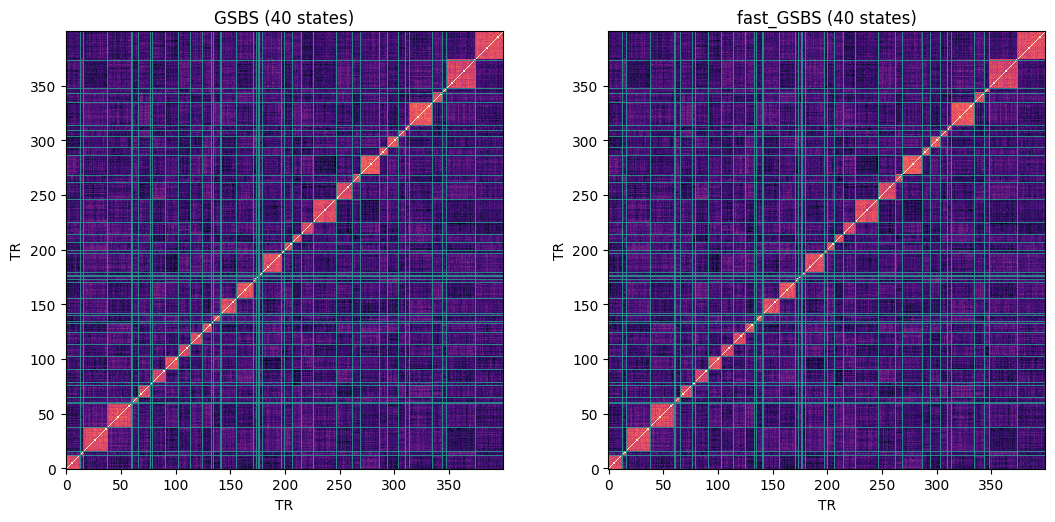

In [6]:
import matplotlib.pyplot as plt
C = np.corrcoef(x)                       # time × time pattern correlation
b_slow = np.where(g_slow.deltas > 0)[0]
b_fast = np.where(g_fast.deltas > 0)[0]

fig, ax = plt.subplots(1, 2, figsize=(11, 5.2))
for a, (bt, ttl) in zip(ax, [(b_slow, f"GSBS ({g_slow.nstates} states)"),
                             (b_fast, f"fast_GSBS ({g_fast.nstates} states)")]):
    a.imshow(C, cmap="magma", origin="lower", interpolation="nearest")
    for tp in bt:
        a.axhline(tp - 0.5, color="#2a9d8f", lw=0.6)
        a.axvline(tp - 0.5, color="#2a9d8f", lw=0.6)
    a.set_title(ttl); a.set_xlabel("TR"); a.set_ylabel("TR")
plt.tight_layout(); plt.show()

# If your fork has plotting helpers, they work on both objects, e.g.:
# g_fast.plot_boundaries(...)   # inherited from your GSBS

## 6 · t-distance curves (state-number selection)

Both models pick the number of states from the peak of the t-distance curve —
these should lie exactly on top of each other.

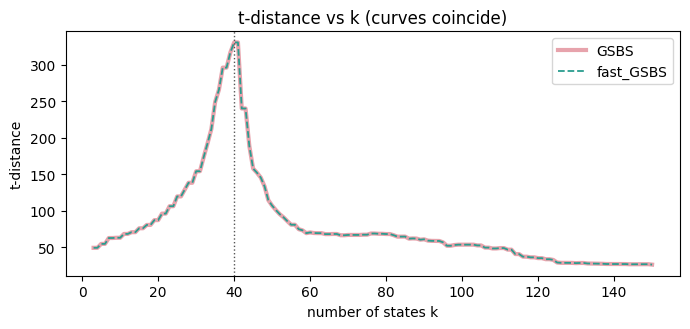

In [7]:
k = np.arange(len(g_slow.tdists))
m = g_slow.tdists != 0
plt.figure(figsize=(7, 3.4))
plt.plot(k[m], g_slow.tdists[m], color="#d1495b", lw=3, alpha=0.5, label="GSBS")
plt.plot(k[m], g_fast.tdists[m], color="#2a9d8f", lw=1.3, ls="--", label="fast_GSBS")
plt.axvline(g_fast.nstates, color="#555", ls=":", lw=1)
plt.xlabel("number of states k"); plt.ylabel("t-distance"); plt.legend()
plt.title("t-distance vs k (curves coincide)"); plt.tight_layout(); plt.show()

## Notes

- `fast_GSBS` returns **bit-identical** boundaries and t-distances to `GSBS`;
  only the runtime differs.
- The speedup grows with the number of timepoints `T`, so larger runs benefit most.
- Feature count `V` barely affects `fast_GSBS`, so 400 voxels is cheap for it.
- For a full search set `KMAX = T // 2`; for a quicker check keep it small.